<a href="https://colab.research.google.com/github/ItzNotCheetah/XGB-Cascade-Classifier/blob/main/xgb_idk_cascade_router.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cost-Sensitive Real-Time Cascading Router Engine
This notebook implements a dynamic IDK ("I Don't Know") cascade scheduling framework using real PyTorch feature extractions on the **CIFAR-100** dataset combined with an asymmetric, cost-sensitive XGBoost meta-classifier and an early-exit strategy.

Models A/B/C are genuinely pretrained on CIFAR-100 (via `chenyaofo/pytorch-cifar-models`) rather than randomly initialized, so correctness/confidence signals reflect real model behavior instead of noise.

### **1. Environment Configuration**
This cell establishes the execution environment by installing core dependencies. The pipeline relies on **PyTorch** and **Torchvision** for deep feature extraction from native computer vision backbones, **XGBoost** for the asymmetric meta-routing engine, and **Scikit-Learn** and **Pandas** for empirical data partitioning, telemetry logging, and statistical alignment.

In [1]:
!pip install xgboost scikit-learn pandas numpy torch torchvision

### **2. Execution Telemetry & Device Allocation**
Imports the structural components required for the cascade pipeline. Hardware execution is dynamically bound to an available NVIDIA CUDA runtime device wrapper to profile physical hardware execution footprints and accurately measure Wall-clock latencies (via `time.perf_counter`), ensuring the system benchmarks reflect true edge deployment environments rather than theoretical FLOP estimates.

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import xgboost as xgb
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using execution device: {device}")

Using execution device: cuda


### **3. Multi-Tier Deep Feature Extractors & Dataset Ingestion**
Instantiates a three-tier model cascade consisting of native, pre-trained convolutional neural networks optimized for the CIFAR-100 taxonomy:
* **Model A (Front-End Edge Model):** A lightweight ResNet-20 backbone designed for ultra-low latency, front-line inference filtering.
* **Model B (Intermediate Governor Model):** A ResNet-32 architecture representing a mid-tier computational compromise.
* **Model C (Heavy Expert Fallback Model):** A highly parameterized ResNet-56 architecture serving as the high-capacity, late-stage expert oracle.

The validation partition is ingested, standardized utilizing native CIFAR-100 normalization parameters, and structured into a deterministic subset to gather realistic uncertainty signals.

In [3]:
print("Loading CIFAR-100 native pretrained networks from torch.hub...")

# Model A: Front-End Lightweight Model (ResNet-20, pretrained on CIFAR-100)
model_a = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet20", pretrained=True).to(device)
model_a.eval()

# Model B: Intermediate Model (ResNet-32, pretrained on CIFAR-100)
model_b = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet32", pretrained=True).to(device)
model_b.eval()

# Model C: Heavy Expert Fallback Model (ResNet-56, pretrained on CIFAR-100)
model_c = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet56", pretrained=True).to(device)
model_c.eval()

# Configure data transformation using native CIFAR-100 normalization metrics (32x32 resolution)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
])

# Download the CIFAR-100 validation split
val_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
torch.manual_seed(42)
indices = torch.randperm(len(val_dataset))[:10000] # 10000 sample evaluation subset
val_subset = torch.utils.data.Subset(val_dataset, indices)
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=32, shuffle=False)

print("Models and CIFAR-100 dataset loaded successfully.")

Loading CIFAR-100 native pretrained networks from torch.hub...


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Models and CIFAR-100 dataset loaded successfully.


### **4. Physical Execution Footprint Profiling**
Rather than relying on theoretical proxy metrics like FLOPs or parameter counts, this cell directly profiles the physical execution footprint of each tier on the hardware runtime. Following a standard GPU warmup cycle to eliminate execution anomalies, it isolates the per-sample execution latency ($\tau_A, \tau_B, \tau_C$) in milliseconds. These empirical constants are directly injected into the downstream downstream cost functions to balance the accuracy-latency trade-off.

In [4]:
def measure_latency(model, sample_batch, n_reps=50, device=device):
    model.eval()
    with torch.no_grad():
        for _ in range(10): # Warmup
            _ = model(sample_batch)
        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        for _ in range(n_reps):
            _ = model(sample_batch)
        if device.type == "cuda":
            torch.cuda.synchronize()
        end = time.perf_counter()

    return (end - start) / n_reps * 1000 / sample_batch.size(0)

sample_batch = next(iter(val_loader))[0].to(device)
print("Profiling physical execution footprints on current hardware...")
LATENCY_A = measure_latency(model_a, sample_batch)
LATENCY_B = measure_latency(model_b, sample_batch)
LATENCY_C = measure_latency(model_c, sample_batch)
print(f"\n[METRIC] Measured Latencies — Model A: {LATENCY_A:.3f} ms, Model B: {LATENCY_B:.3f} ms, Model C: {LATENCY_C:.3f} ms")

Profiling physical execution footprints on current hardware...

[METRIC] Measured Latencies — Model A: 0.354 ms, Model B: 0.478 ms, Model C: 0.711 ms


### **5. Telemetry Extraction & Asymmetric Meta-Router Training**
This cell implements the core logic of the **Delta Cascade Model**. It executes a forward pass through the front-end network (Model A) to construct multi-parameter uncertainty vectors per sample:
1.  **Maximum Softmax Probability (Confidence):** Evaluated against a hard $E_{th} = 0.90$ early-exit barrier for immediate edge termination.
2.  **Shannon Entropy:** Quantifying overall prediction dispersion.
3.  **Classification Margin:** The delta between the top-two predicted logits to measure decision boundary ambiguity.

**Ground-Truth Routing Policy:** A sample is flagged for routing ($y=1$) *only* if the front-end fails but the late-stage expert succeeds.

To map this to real-world Service Level Agreements (SLAs), an asymmetric misclassification multiplier ($scale\_pos\_weight$) is derived:
$$\omega = \frac{\text{Cost of Missed Fallback}}{\text{Cost of Unnecessary Fallback}} \propto \frac{1.0}{\tau_C}$$
This explicitly penalizes the meta-router for missing samples that the expert could have saved, while factoring in the latency penalty of an unnecessary invocation. An XGBoost classifier is then trained on these telemetry vectors under this cost-sensitive objective.

In [5]:
EARLY_EXIT_THRESHOLD = 0.90  # Confident samples exit here immediately
features_list = []
targets_list = []

print("Extracting multi-parameter uncertainty vectors for the Delta Model configuration...")

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Evaluate Front-End Model A (ResNet-20)
        outputs_a = model_a(images)
        probs_a = torch.softmax(outputs_a, dim=1)
        conf_A, preds_a = torch.max(probs_a, dim=1)
        entropy_A = -torch.sum(probs_a * torch.log(probs_a + 1e-6), dim=1)
        top_2_vals, _ = torch.topk(probs_a, k=2, dim=1)
        margin_A = top_2_vals[:, 0] - top_2_vals[:, 1]

        # 2. Evaluate Expert Model C (ResNet-56)
        outputs_c = model_c(images)
        _, preds_c = torch.max(outputs_c, dim=1)

        # Ground Truth Policy: Route if A fails BUT the Expert C succeeds
        actual_route_to_c = ((preds_a != labels) & (preds_c == labels)).long()

        for i in range(images.size(0)):
            should_route = actual_route_to_c[i].item()

            # Enforce early exit policy in telemetry training data
            if conf_A[i].item() >= EARLY_EXIT_THRESHOLD:
                should_route = 0

            features_list.append({
                'confidence': conf_A[i].item(),
                'entropy': entropy_A[i].item(),
                'margin': margin_A[i].item(),
                'correct_a': (preds_a[i] == labels[i]).item(),
                'correct_c': (preds_c[i] == labels[i]).item()
            })
            targets_list.append(should_route)

delta_df = pd.DataFrame(features_list)
delta_df['target_route'] = targets_list

# Split Data
X = delta_df[['confidence', 'entropy', 'margin']]
y = delta_df['target_route']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
test_raw = delta_df.loc[X_test.index].reset_index(drop=True)

# Recalculate Asymmetric Costs
cost_missed_fallback = 1.0
cost_unnecessary_fallback = LATENCY_C
asymmetric_multiplier = cost_missed_fallback / max(cost_unnecessary_fallback, 1e-6)

num_pos = np.sum(y_train == 1)
num_neg = np.sum(y_train == 0)
base_weight = num_neg / max(num_pos, 1)
tuned_scale_pos_weight = base_weight * asymmetric_multiplier

# Train Meta-Router
router_engine = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=tuned_scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
router_engine.fit(X_train, y_train)
print("Delta Model Meta-Router successfully trained.")

Extracting multi-parameter uncertainty vectors for the Delta Model configuration...
Delta Model Meta-Router successfully trained.


### **6. Pareto Frontier Evaluation Engine**
Evaluates the downstream efficacy of the Delta Cascade framework by sweeping the router's decision threshold ($\theta \in [0.05, 0.95]$). The performance is benchmarked against two static deployment baselines: a **Pure Expert Only** configuration (maximum accuracy, maximum latency) and a **Pure Front-End Only** configuration (minimum latency, compromised accuracy). The metrics log end-to-end accuracy, mean systemic latency per sample, and relative latency savings to construct an empirical Pareto frontier.

In [6]:
def evaluate_delta_cascade(X_te, raw_df):
    eval_size = len(X_te)
    router_probs = router_engine.predict_proba(X_te)[:, 1]
    threshold_sweeps = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.85, 0.95]
    results = []

    # Baseline 1: Pure Expert (Always Model C)
    total_time_expert = LATENCY_C * eval_size
    correct_expert = np.sum(raw_df['correct_c'])
    avg_lat_expert = total_time_expert / eval_size
    acc_expert = correct_expert / eval_size

    results.append({
        'Strategy': 'Pure Expert (Model C Only)',
        'Avg Latency (ms)': round(avg_lat_expert, 4),
        'Accuracy': f"{acc_expert * 100:.2f}%",
        'Latency Saved (%)': '0.00%'
    })

    # Baseline 2: Pure Front-End (Always Model A)
    total_time_a = LATENCY_A * eval_size
    correct_a = np.sum(raw_df['correct_a'])
    avg_lat_a = total_time_a / eval_size
    acc_a = correct_a / eval_size

    results.append({
        'Strategy': 'Pure Front-End (Model A Only)',
        'Avg Latency (ms)': round(avg_lat_a, 4),
        'Accuracy': f"{acc_a * 100:.2f}%",
        'Latency Saved (%)': f"{((avg_lat_expert - avg_lat_a) / avg_lat_expert) * 100:+.2f}%"
    })

    # Sweep Dynamic Meta-Router Framework
    for theta in threshold_sweeps:
        route_decisions = np.where(router_probs >= theta, 1, 0)
        accumulated_latency = 0.0
        correct_predictions = 0

        for idx in range(eval_size):
            accumulated_latency += LATENCY_A

            if raw_df.loc[idx, 'confidence'] >= EARLY_EXIT_THRESHOLD:
                if raw_df.loc[idx, 'correct_a']: correct_predictions += 1
            elif route_decisions[idx] == 1:
                accumulated_latency += LATENCY_C
                if raw_df.loc[idx, 'correct_c']: correct_predictions += 1
            else:
                if raw_df.loc[idx, 'correct_a']: correct_predictions += 1

        avg_lat_cascade = accumulated_latency / eval_size
        acc_cascade = correct_predictions / eval_size
        pct_saved = ((avg_lat_expert - avg_lat_cascade) / avg_lat_expert) * 100

        results.append({
            'Strategy': f'Delta Cascade (θ={theta:.2f})',
            'Avg Latency (ms)': round(avg_lat_cascade, 4),
            'Accuracy': f"{acc_cascade * 100:.2f}%",
            'Latency Saved (%)': f"{pct_saved:.2f}%"
        })

    return pd.DataFrame(results)

delta_results_grid = evaluate_delta_cascade(X_test, test_raw)
delta_results_grid

,Strategy,Avg Latency (ms),Accuracy,Latency Saved (%)
0,Pure Expert (Model C Only),0.7111,72.80%,0.00%
1,Pure Front-End (Model A Only),0.3541,70.25%,+50.21%
2,Delta Cascade (θ=0.05),0.7004,73.10%,1.51%
3,Delta Cascade (θ=0.10),0.6975,73.20%,1.91%
4,Delta Cascade (θ=0.20),0.6972,73.20%,1.96%
5,Delta Cascade (θ=0.30),0.6965,73.25%,2.06%
6,Delta Cascade (θ=0.50),0.6954,73.25%,2.21%
7,Delta Cascade (θ=0.70),0.6183,73.05%,13.06%
8,Delta Cascade (θ=0.85),0.3541,70.25%,50.21%
9,Delta Cascade (θ=0.95),0.3541,70.25%,50.21%


### **7. Meta-Router Inference Micro-Overhead Profiling**
A critical validation step for real-time edge engines. This cell profiles the isolated computational overhead introduced by the XGBoost meta-router itself. By running repeated probability sweeps over the test split, it calculates the per-sample micro-overhead and expresses it as a percentage of the front-end Model A's latency. This demonstrates whether the routing engine introduces a negligible execution footprint relative to the latency it saves.

In [7]:
n_overhead_reps = 100
router_times = []
for _ in range(n_overhead_reps):
    start_router = time.perf_counter()
    _ = router_engine.predict_proba(X_test)
    end_router = time.perf_counter()
    router_times.append((end_router - start_router) / len(X_test) * 1000)

router_overhead_per_sample = np.mean(router_times)
print(f"[METRIC] Router Micro-Overhead: {router_overhead_per_sample:.4f} ms/sample")
print(f"[METRIC] Overhead as % of Model A latency: {(router_overhead_per_sample / LATENCY_A) * 100:.2f}%")

[METRIC] Router Micro-Overhead: 0.0011 ms/sample
[METRIC] Overhead as % of Model A latency: 0.30%


### **8. Pareto Frontier Data Visualization**
Generates a structural visualization of the accuracy-latency design space. By plotting End-to-End Accuracy ($y$-axis) against Average Latency ($x$-axis), the visualization explicitly maps the system's operational characteristics, highlighting how the cost-sensitive Delta Cascade sweep successfully maps out a superior trade-off curve relative to the rigid baseline models.

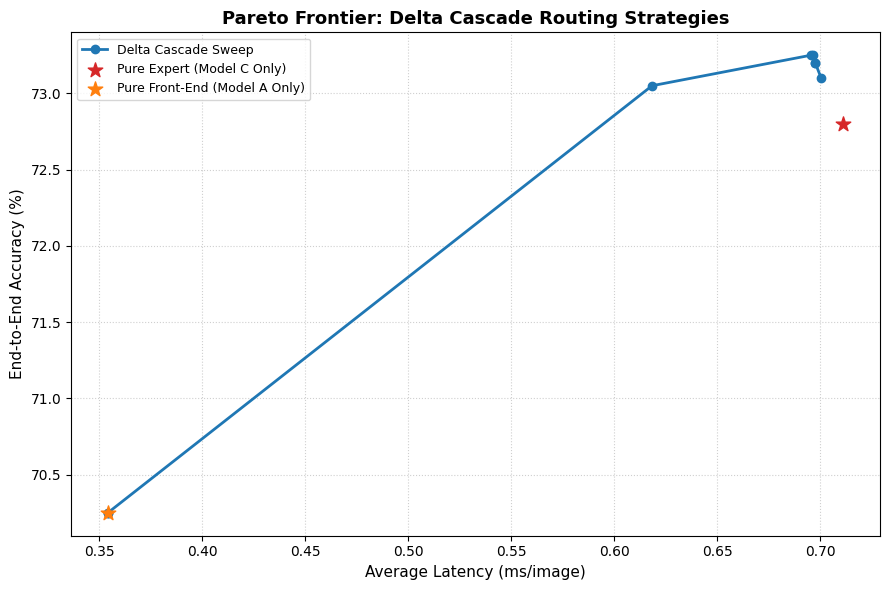

In [8]:
def parse_pct(s):
    return float(s.replace('%', ''))

plot_df = delta_results_grid.copy()
plot_df['latency_val'] = plot_df['Avg Latency (ms)']
plot_df['accuracy_val'] = plot_df['Accuracy'].apply(parse_pct)

fig, ax = plt.subplots(figsize=(9, 6))
cascade_rows = plot_df[plot_df['Strategy'].str.contains('Delta')]
baseline_rows = plot_df[~plot_df['Strategy'].str.contains('Delta')]

ax.plot(cascade_rows['latency_val'], cascade_rows['accuracy_val'], marker='o', color='tab:blue', linewidth=2, label='Delta Cascade Sweep')
for _, row in baseline_rows.iterrows():
    ax.scatter(row['latency_val'], row['accuracy_val'], s=120, marker='*', color='tab:red' if 'Expert' in row['Strategy'] else 'tab:orange', label=row['Strategy'], zorder=5)

ax.set_xlabel('Average Latency (ms/image)', fontsize=11)
ax.set_ylabel('End-to-End Accuracy (%)', fontsize=11)
ax.set_title('Pareto Frontier: Delta Cascade Routing Strategies', fontsize=13, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

### **9. Multi-Seed Statistical Robustness & Validation Framework**
To ensure the algorithmic routing decisions are stable and not an artifact of data partitioning, this cell runs a multi-seed statistical robustness check across 5 independent random data configurations. It re-extracts telemetry, re-tunes the asymmetric penalties, and re-trains the meta-router from scratch for each seed. It outputs aggregate mean and standard deviation statistics for systemic latency, end-to-end accuracy, and **Skip Recall** (the percentage of critical expert corrections successfully caught by the router).

In [9]:
def run_single_trial(seed, n_samples=2000, threshold=0.10):
    torch.manual_seed(seed)
    trial_indices = torch.randperm(len(val_dataset))[:n_samples]
    trial_subset = torch.utils.data.Subset(val_dataset, trial_indices)
    trial_loader = torch.utils.data.DataLoader(trial_subset, batch_size=32, shuffle=False)

    feats, targs = [], []
    with torch.no_grad():
        for images, labels in trial_loader:
            images, labels = images.to(device), labels.to(device)
            outputs_a = model_a(images)
            probs_a = torch.softmax(outputs_a, dim=1)
            conf_A, preds_a = torch.max(probs_a, dim=1)
            entropy_A = -torch.sum(probs_a * torch.log(probs_a + 1e-6), dim=1)
            top_2_vals, _ = torch.topk(probs_a, k=2, dim=1)
            margin_A = top_2_vals[:, 0] - top_2_vals[:, 1]

            outputs_b = model_b(images)
            _, preds_b = torch.max(outputs_b, dim=1)
            outputs_c = model_c(images)
            _, preds_c = torch.max(outputs_c, dim=1)

            actual_skip_signal = ((preds_b != labels) & (preds_c == labels)).long()

            for i in range(images.size(0)):
                should_skip = actual_skip_signal[i].item()
                if conf_A[i].item() >= EARLY_EXIT_THRESHOLD:
                    should_skip = 0

                feats.append({
                    'confidence': conf_A[i].item(),
                    'entropy': entropy_A[i].item(),
                    'margin': margin_A[i].item(),
                    'correct_a': (preds_a[i] == labels[i]).item(),
                    'correct_b': (preds_b[i] == labels[i]).item(),
                    'correct_c': (preds_c[i] == labels[i]).item(),
                    'target_skip': should_skip
                })
                targs.append(should_skip)

    df = pd.DataFrame(feats)
    X_tr, X_te, y_tr, y_te = train_test_split(df[['confidence', 'entropy', 'margin']], df['target_skip'], test_size=0.2, random_state=seed)
    raw_te = df.loc[X_te.index].reset_index(drop=True)

    num_pos = np.sum(y_tr == 1)
    num_neg = np.sum(y_tr == 0)
    base_w = num_neg / max(num_pos, 1)
    tuned_w = base_w * asymmetric_multiplier

    router = xgb.XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, scale_pos_weight=tuned_w, eval_metric='logloss', random_state=seed)
    router.fit(X_tr, y_tr)

    probs = router.predict_proba(X_te)[:, 1]
    decisions = np.where(probs >= threshold, 0, 1)

    total_latency, correct, needed_skips, hit_skips = 0.0, 0, 0, 0
    for idx in range(len(raw_te)):
        total_latency += LATENCY_A
        if raw_te.loc[idx, 'target_skip'] == 1: needed_skips += 1

        if raw_te.loc[idx, 'confidence'] >= EARLY_EXIT_THRESHOLD:
            if raw_te.loc[idx, 'correct_a']: correct += 1
        elif decisions[idx] == 0:  # Skip
            total_latency += LATENCY_C
            if raw_te.loc[idx, 'target_skip'] == 1: hit_skips += 1
            if raw_te.loc[idx, 'correct_c']: correct += 1
        else:  # Route Normal
            total_latency += LATENCY_B
            if raw_te.loc[idx, 'correct_b']: correct += 1
            else:
                total_latency += LATENCY_C
                if raw_te.loc[idx, 'correct_c']: correct += 1

    return {
        'seed': seed, 'avg_latency': total_latency / len(raw_te),
        'accuracy': (correct / len(raw_te)) * 100,
        'skip_recall': (hit_skips / needed_skips) * 100 if needed_skips > 0 else 0
    }

print("Running multi-seed robustness check...")
trial_results = [run_single_trial(seed=s) for s in [1, 2, 3, 4, 5]]
trial_df = pd.DataFrame(trial_results)
print("\n--- Per-Seed Results ---")
print(trial_df)

print("\n--- Aggregate Statistics (mean ± std across 5 seeds) ---")
print(f"Avg Latency:  {trial_df['avg_latency'].mean():.2f} ± {trial_df['avg_latency'].std():.2f} ms")
print(f"Accuracy:     {trial_df['accuracy'].mean():.2f} ± {trial_df['accuracy'].std():.2f} %")
print(f"Skip Recall:  {trial_df['skip_recall'].mean():.2f} ± {trial_df['skip_recall'].std():.2f} %")

Running multi-seed robustness check...

--- Per-Seed Results ---
   seed  avg_latency  accuracy  skip_recall
0     1     0.717381     74.00   100.000000
1     2     0.700830     72.75    97.297297
2     3     0.732155     74.50    97.222222
3     4     0.714990     72.25    97.777778
4     5     0.689551     75.25   100.000000

--- Aggregate Statistics (mean ± std across 5 seeds) ---
Avg Latency:  0.71 ± 0.02 ms
Accuracy:     73.75 ± 1.24 %
Skip Recall:  98.46 ± 1.42 %
